In [9]:
import random
from pathlib import Path

import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [10]:
def read_tif_rgb(path):
    with rasterio.open(path) as src:
        arr = src.read()  # (bands, H, W)

    # Use first 3 bands for RGB visualization
    rgb = arr[:3].transpose(1, 2, 0).astype(np.float32)

    # Robust normalization
    lo = np.percentile(rgb, 2)
    hi = np.percentile(rgb, 98)
    if hi <= lo:
        hi = lo + 1.0
    rgb = (rgb - lo) / (hi - lo)
    rgb = np.clip(rgb, 0, 1)
    return rgb


def parse_yolo_labels(label_path):
    boxes = []
    if not label_path.exists():
        return boxes

    for line in label_path.read_text().splitlines():
        if not line.strip():
            continue
        cls, xc, yc, w, h = map(float, line.split())
        boxes.append((int(cls), xc, yc, w, h))
    return boxes


def yolo_to_pixel(box, W, H):
    cls, xc, yc, w, h = box
    bw = w * W
    bh = h * H
    x0 = xc * W - bw / 2
    y0 = yc * H - bh / 2
    return cls, x0, y0, bw, bh


def show_chip_with_labels(
    tif_path,
    label_path,
    class_names=None,
):
    from pathlib import Path
    import matplotlib.pyplot as plt
    from matplotlib.patches import Rectangle

    tif_path = Path(tif_path)
    label_path = Path(label_path)

    rgb = read_tif_rgb(tif_path)
    H, W = rgb.shape[:2]
    boxes = parse_yolo_labels(label_path)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(rgb)
    ax.set_title(f"{tif_path.name}  |  {len(boxes)} boxes")
    ax.axis("off")

    for box in boxes:
        cls, x0, y0, bw, bh = yolo_to_pixel(box, W, H)

        # Thin red bbox
        rect = Rectangle(
            (x0, y0),
            bw,
            bh,
            fill=False,
            edgecolor="red",
            linewidth=0.8,
            alpha=0.9
        )
        ax.add_patch(rect)

        # Class label
        if class_names and cls in class_names:
            label_text = class_names[cls]
        else:
            label_text = str(cls)

        ax.text(
            x0,
            y0,
            label_text,
            fontsize=9,
            color="black",
            verticalalignment="top",
            horizontalalignment="left",
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.5,
                pad=2
            )
        )

    plt.tight_layout()
    plt.show()

In [29]:
import os
total = 0
for mode in ['train','val','test']:
    cnt = len(os.listdir(f'/mnt/sds-hd/sd17f001/ygrin/silverways/greenspaces/experiments_datasets/final_subtiles_640_20/yolo_rgbih/images/{mode}'))
    print(mode, '=',cnt)
    total = total + cnt
print('Total = ',total)

train = 2482
val = 297
test = 186
Total =  2965


In [37]:
import re
from pathlib import Path
import pandas as pd

ROOT = Path("/mnt/sds-hd/sd17f001/ygrin/silverways/greenspaces/experiments_datasets/final_subtiles_640_20/yolo_rgbih")
SPLITS = ["train", "val", "test"]

# finds tile_id like 32_409_5315 anywhere in the filename
tile_pat = re.compile(r"(32_(\d+)_(\d+))")

img_exts = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".webp"}

def extract_tile_parts(stem: str):
    m = tile_pat.search(stem)
    if not m:
        return None, None, None
    tile_id = m.group(1)
    e = int(m.group(2))  # easting_km
    n = int(m.group(3))  # northing_km
    return tile_id, e, n

def city_from_en(e: int, n: int) -> str:
    if e is None or n is None:
        return "UNKNOWN"
    # your clusters:
    if 409 <= e <= 418 and 5314 <= n <= 5320:
        return "freiburg"
    if 452 <= e <= 465 and 5422 <= n <= 5434:
        return "karlsruhe"
    if 459 <= e <= 468 and 5480 <= n <= 5487:
        return "mannheim"
    return "UNKNOWN"

def count_instances(label_path: Path) -> int:
    if not label_path.exists():
        return 0
    with label_path.open("r") as f:
        return sum(1 for line in f if line.strip())

rows = []

for split in SPLITS:
    img_dir = ROOT / "images" / split
    lbl_dir = ROOT / "labels" / split

    for img_path in img_dir.iterdir():
        if img_path.suffix.lower() not in img_exts:
            continue

        tile_id, e, n = extract_tile_parts(img_path.stem)
        city = city_from_en(e, n)

        inst = count_instances(lbl_dir / f"{img_path.stem}.txt")

        rows.append({
            "city": city,
            "split": split,
            "image": img_path.name,
            "tile_id": tile_id,
            "instances": inst,
        })

df = pd.DataFrame(rows)

summary = (
    df.groupby(["city", "split"], as_index=False)
      .agg(
          n_images=("image", "nunique"),
          n_instances=("instances", "sum"),
      )
      .sort_values(["city", "split"])
)

print(summary.to_string(index=False))

# optional: see how much fell outside your ranges
print("\nUNKNOWN breakdown:")
print(df[df["city"] == "UNKNOWN"].groupby("split").size())


     city split  n_images  n_instances
 freiburg  test        37         1701
 freiburg train       723        35791
 freiburg   val        39         1426
karlsruhe  test        86         3459
karlsruhe train      1012        57812
karlsruhe   val       107         3883
 mannheim  test        63         2953
 mannheim train       747        34838
 mannheim   val       151         6437

UNKNOWN breakdown:
Series([], dtype: int64)


In [40]:
import re
from pathlib import Path
import pandas as pd

ROOT = Path("/mnt/sds-hd/sd17f001/ygrin/silverways/greenspaces/experiments_datasets/final_subtiles_640_20/yolo_rgbih")
SPLITS = ["train", "val", "test"]

# tile_id like: 32_409_5315
tile_pat = re.compile(r"(32_(\d+)_(\d+))")
img_exts = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".webp"}

def extract_tile_parts(stem: str):
    m = tile_pat.search(stem)
    if not m:
        return None, None, None
    tile_id = m.group(1)
    e = int(m.group(2))  # easting_km
    n = int(m.group(3))  # northing_km
    return tile_id, e, n

def city_from_en(e: int, n: int) -> str:
    if e is None or n is None:
        return "UNKNOWN"
    # your clusters:
    if 409 <= e <= 418 and 5314 <= n <= 5320:
        return "Freiburg im Breisgau"
    if 452 <= e <= 466 and 5422 <= n <= 5434:
        return "Karlsruhe"
    if 459 <= e <= 468 and 5480 <= n <= 5487:
        return "Mannheim"
    return "UNKNOWN"

def count_instances(label_path: Path) -> int:
    if not label_path.exists():
        return 0
    with label_path.open("r") as f:
        return sum(1 for line in f if line.strip())

rows = []
for split in SPLITS:
    img_dir = ROOT / "images" / split
    lbl_dir = ROOT / "labels" / split

    for img_path in img_dir.iterdir():
        if img_path.suffix.lower() not in img_exts:
            continue

        stem = img_path.stem
        tile_id, e, n = extract_tile_parts(stem)
        city = city_from_en(e, n)
        inst = count_instances(lbl_dir / f"{stem}.txt")

        rows.append({
            "City": city,
            "Split": split,
            "tile_id": tile_id,
            "image": img_path.name,
            "Instances": inst,
        })

df = pd.DataFrame(rows)

# ---- aggregate: Tiles, Subtiles, Instances per City x Split
agg = (
    df.groupby(["City", "Split"], as_index=False)
      .agg(
          Tiles=("tile_id", lambda s: s.dropna().nunique()),
          Subtiles=("image", "nunique"),
          Instances=("Instances", "sum"),
      )
)

# ---- build wide table like your example
wide = agg.pivot(index="City", columns="Split", values=["Tiles", "Subtiles", "Instances"])
wide = wide.reindex(columns=pd.MultiIndex.from_product([["Tiles","Subtiles","Instances"], SPLITS]))

# Add Total row
total = pd.DataFrame(wide.sum(axis=0)).T
total.index = ["Total"]
wide = pd.concat([wide, total], axis=0)

# Optional: order cities
order = ["Mannheim", "Karlsruhe", "Freiburg im Breisgau", "UNKNOWN", "Total"]
wide = wide.reindex([c for c in order if c in wide.index])

# Make it pretty for printing
wide.columns = [f"{metric}_{split.capitalize()}" for metric, split in wide.columns]
wide = wide.fillna(0).astype(int)

print(wide.to_string())

                      Tiles_Train  Tiles_Val  Tiles_Test  Subtiles_Train  Subtiles_Val  Subtiles_Test  Instances_Train  Instances_Val  Instances_Test
Mannheim                       31          6           6             747           151             63            34838           6437            2953
Karlsruhe                      44          6           9            1012           107             86            57812           3883            3459
Freiburg im Breisgau           36          2           3             723            39             37            35791           1426            1701
Total                         111         14          18            2482           297            186           128441          11746            8113


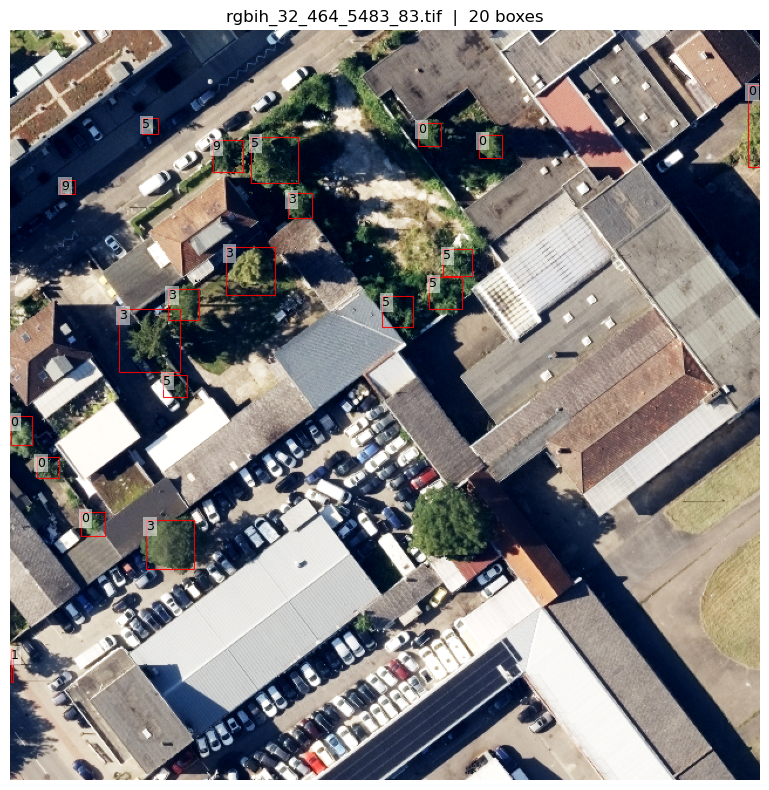

In [21]:
images_dir = Path("/mnt/sds-hd/sd17f001/ygrin/silverways/greenspaces/experiments_datasets/final_subtiles_640_20/yolo_rgbih/images/train")
labels_dir = Path("/mnt/sds-hd/sd17f001/ygrin/silverways/greenspaces/experiments_datasets/final_subtiles_640_20/yolo_rgbih/labels/train")

img = images_dir / "rgbih_32_464_5483_83.tif"
lbl = labels_dir / "rgbih_32_464_5483_83.txt"

show_chip_with_labels(img, lbl)

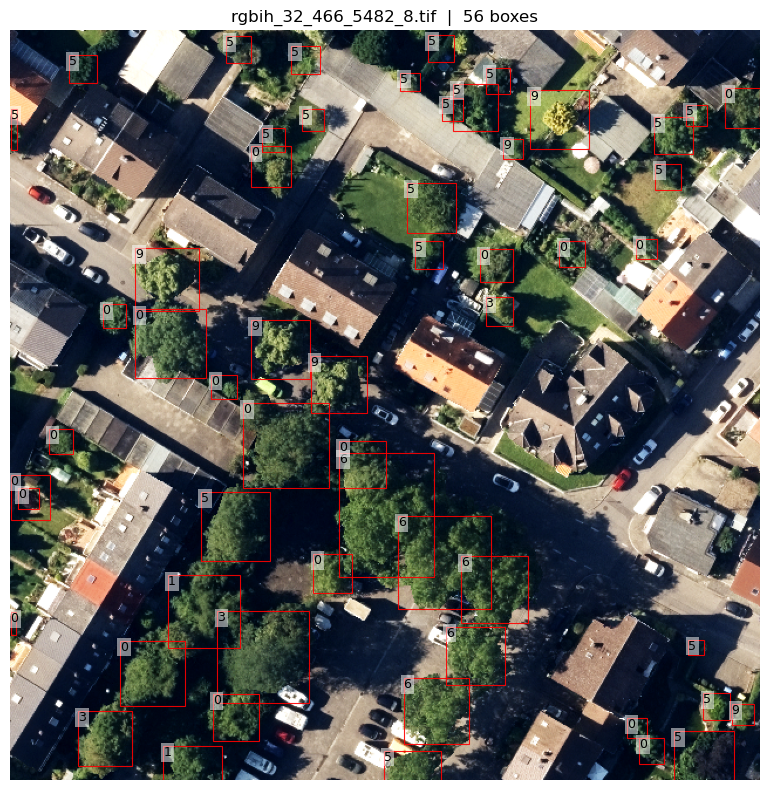

In [20]:
images = list(images_dir.glob("*.tif"))
img = random.choice(images)

lbl = labels_dir / f"{img.stem}.txt"

show_chip_with_labels(img, lbl)